<a href="https://colab.research.google.com/github/rah-ds/Cloud-Autoscaling-using-RL/blob/bmcgregor%2Fsimulator-refactor/notebooks/Experiment_Double_DQN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Experiment 2 - Double DQN

This notebook, titled 'Experiment 2 - Double DQN', focuses on training and evaluating a Double Deep Q-Network (Double DQN) agent for an autoscaling environment.

The key steps covered in this notebook are:

1.  **File Downloads**: Necessary Python scripts (`Double_DQN_Agent.py`, `autoscaling_env.py`, `DQN_Utils.py`) are downloaded from a GitHub repository.
2.  **Google Drive Integration**: Google Drive is mounted, and a directory for saving RL model checkpoints is created.
3.  **Data Loading and Preprocessing**: A CPU usage dataset (`df_usage.csv`) is loaded from Google Drive into a pandas DataFrame, and some initial preprocessing (dropping a column) is performed.
4.  **Environment Setup**: The `autoscaling_env.py` and `DQN_Utils.py` are imported, and the `AutoScalingEnv` is initialized with the loaded data.
5.  **Double DQN Agent Initialization**: A `DoubleDQNAgent` is instantiated with the environment's observation and action space, configured to use a GPU if available.
6.  **Training**: The Double DQN agent is trained over 500 episodes using the `train_agent` function, with defined hyperparameters for epsilon decay.
7.  **Model Saving**: The trained Double DQN model's weights are saved to Google Drive.
8.  **Learning Curve Visualization**: A plot is generated to visualize the agent's learning progress, showing episode returns and a 20-episode moving average.
9.  **Evaluation**: The trained agent is evaluated on both validation and test datasets for 10 episodes each. Evaluation metrics include current capacity, CPU demand, utilization, and reward over time, which are then plotted for visualization.

# Download Files

In [ ]:
raw_url_dqn_agent = 'https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/Double_DQN_Agent.py'
local_filename_dqn_agent = 'Double_DQN_Agent.py'
!wget -O {local_filename_dqn_agent} {raw_url_dqn_agent}

--2025-11-28 23:11:44--  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/Double_DQN_Agent.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4132 (4.0K) [text/plain]
Saving to: ‘Double_DQN_Agent.py’

Double_DQN_Agent.py 100%[===================>]   4.04K  --.-KB/s    in 0s      

2025-11-28 23:11:44 (79.5 MB/s) - ‘Double_DQN_Agent.py’ saved [4132/4132]



In [ ]:

raw_url = 'https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/autoscaling_env.py'

# Replace with the desired local filename for your script
local_filename = 'autoscaling_env.py'

!wget -O {local_filename} {raw_url}

--2025-11-28 23:11:45--  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/autoscaling_env.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7891 (7.7K) [text/plain]
Saving to: ‘autoscaling_env.py’

autoscaling_env.py  100%[===================>]   7.71K  --.-KB/s    in 0s      

2025-11-28 23:11:45 (93.5 MB/s) - ‘autoscaling_env.py’ saved [7891/7891]



In [ ]:
raw_url_utilities = 'https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/DQN_Utils.py'
local_filename_utilities = 'DQN_Utils.py'
!wget -O {local_filename_utilities} {raw_url_utilities}

--2025-11-28 23:11:48--  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/DQN_Utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9975 (9.7K) [text/plain]
Saving to: ‘DQN_Utils.py’

DQN_Utils.py        100%[===================>]   9.74K  --.-KB/s    in 0s      

2025-11-28 23:11:48 (91.9 MB/s) - ‘DQN_Utils.py’ saved [9975/9975]



In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/RL_Checkpoints

Mounted at /content/drive


In [ ]:
import pandas as pd

df_usage = pd.read_csv('/content/drive/MyDrive/df_usage.csv')
display(df_usage.head())

,time_window,avg_cpu,avg_mem,active_machines
0,1970-01-01 00:05:00+00:00,0.006623,0.004912,9525
1,1970-01-01 00:06:00+00:00,0.003254,0.002733,3805
2,1970-01-01 00:07:00+00:00,0.003070,0.002770,4167
3,1970-01-01 00:08:00+00:00,0.001950,0.001823,4338
4,1970-01-01 00:09:00+00:00,0.001689,0.001468,5545


In [ ]:
df_usage = df_usage.drop(columns=['active_machines']).copy()
display(df_usage.head())

,time_window,avg_cpu,avg_mem
0,1970-01-01 00:05:00+00:00,0.006623,0.004912
1,1970-01-01 00:06:00+00:00,0.003254,0.002733
2,1970-01-01 00:07:00+00:00,0.003070,0.002770
3,1970-01-01 00:08:00+00:00,0.001950,0.001823
4,1970-01-01 00:09:00+00:00,0.001689,0.001468


In [ ]:
import sys
# Add the current directory to the system path to ensure Colab can find your local .py files
sys.path.append('.')


# Training

In [ ]:
from DQN_Utils import train_agent, evaluate_agent, QNetwork, ReplayBuffer
from Double_DQN_Agent import DoubleDQNAgent
from autoscaling_env import AutoScalingEnv
import numpy as np
import sys
import matplotlib.pyplot as plt
import torch # Import torch to define the device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 1. Initialize the AutoScalingEnv environment for the Double DQN agent
env_ddqn = AutoScalingEnv(df_usage)

# 2. Instantiate the DoubleDQNAgent
agent_ddqn = DoubleDQNAgent(
    observation_space_shape=env_ddqn.observation_space.shape,
    action_space_size=env_ddqn.action_space.n,
    seed=0,
    device = device
)

# 3. Define the training hyperparameters for the Double DQN agent
num_episodes_ddqn = 500
max_steps_per_episode_ddqn = 1000
epsilon_start_ddqn = 1.0
epsilon_end_ddqn = 0.05
epsilon_decay_ddqn = 0.999

# 4. Call the train_agent function
ddqn_training_scores = train_agent(
    agent_ddqn,
    env_ddqn,
    num_episodes_ddqn,
    max_steps_per_episode_ddqn,
    epsilon_start_ddqn,
    epsilon_end_ddqn,
    epsilon_decay_ddqn,
    split="train",
    use_random_windows = True
)

print("DDQN Training Scores:", ddqn_training_scores[:5])



Using device: cuda
Episode 0	Average Score: -20600.76
Episode 10	Average Score: -13289.09
Episode 20	Average Score: -9271.44
Episode 30	Average Score: -12123.50
Episode 40	Average Score: -5103.50
Episode 50	Average Score: -8340.14
Episode 60	Average Score: -4481.01
Episode 70	Average Score: -4639.17
Episode 80	Average Score: -5881.88
Episode 90	Average Score: -3366.74
Episode 100	Average Score: -4004.39
Episode 110	Average Score: -3956.84
Episode 120	Average Score: -4922.26
Episode 130	Average Score: -2330.54
Episode 140	Average Score: -4469.34
Episode 150	Average Score: -3398.31
Episode 160	Average Score: -2167.84
Episode 170	Average Score: -2971.99
Episode 180	Average Score: -2096.40
Episode 190	Average Score: -2358.94
Episode 200	Average Score: -1708.33
Episode 210	Average Score: -1828.04
Episode 220	Average Score: -2237.51
Episode 230	Average Score: -2064.68
Episode 240	Average Score: -1712.92
Episode 250	Average Score: -1788.12
Episode 260	Average Score: -1754.43
Episode 270	Avera

In [ ]:
# === Save trained DDQN model ===
checkpoint_path = "/content/drive/MyDrive/RL_Checkpoints/double_dqn_checkpoint.pth"
agent_ddqn.save("/content/drive/MyDrive/RL_Checkpoints/double_dqn_checkpoint.pth")

print(f"Model saved to: {checkpoint_path}")


Model saved to: /content/drive/MyDrive/RL_Checkpoints/double_dqn_checkpoint.pth


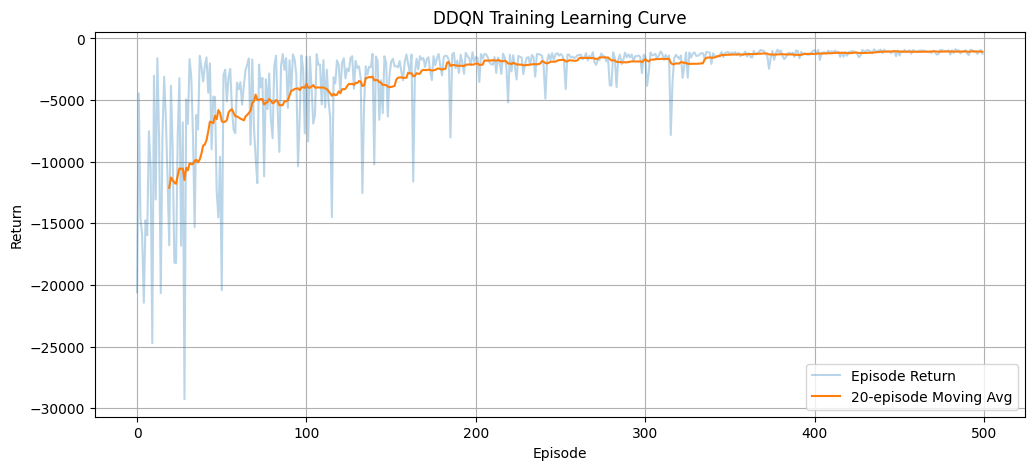

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Build a DataFrame of training returns
training_df = pd.DataFrame({
    "episode": np.arange(len(ddqn_training_scores)),
    "return": ddqn_training_scores
})

# 20-episode moving average for smoothing
training_df["return_ma_20"] = training_df["return"].rolling(window=20).mean()

# Plot learning curve
plt.figure(figsize=(12, 5))
plt.plot(training_df["episode"], training_df["return"],
         alpha=0.3, label="Episode Return")
plt.plot(training_df["episode"], training_df["return_ma_20"],
         label="20-episode Moving Avg")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("DDQN Training Learning Curve")
plt.legend()
plt.grid(True)
plt.show()


# Evaluation

Evaluation Episode 1	Score: -867.06
Evaluation Episode 2	Score: -902.02
Evaluation Episode 3	Score: -867.75
Evaluation Episode 4	Score: -899.14
Evaluation Episode 5	Score: -895.84
Evaluation Episode 6	Score: -903.13
Evaluation Episode 7	Score: -893.53
Evaluation Episode 8	Score: -894.55
Evaluation Episode 9	Score: -866.19
Evaluation Episode 10	Score: -906.64

Average Evaluation Score over 10 episodes: -889.59
Evaluation Episode 1	Score: -848.70
Evaluation Episode 2	Score: -787.19
Evaluation Episode 3	Score: -817.99
Evaluation Episode 4	Score: -759.46
Evaluation Episode 5	Score: -760.51
Evaluation Episode 6	Score: -901.01
Evaluation Episode 7	Score: -774.05
Evaluation Episode 8	Score: -877.38
Evaluation Episode 9	Score: -783.11
Evaluation Episode 10	Score: -759.61

Average Evaluation Score over 10 episodes: -806.90


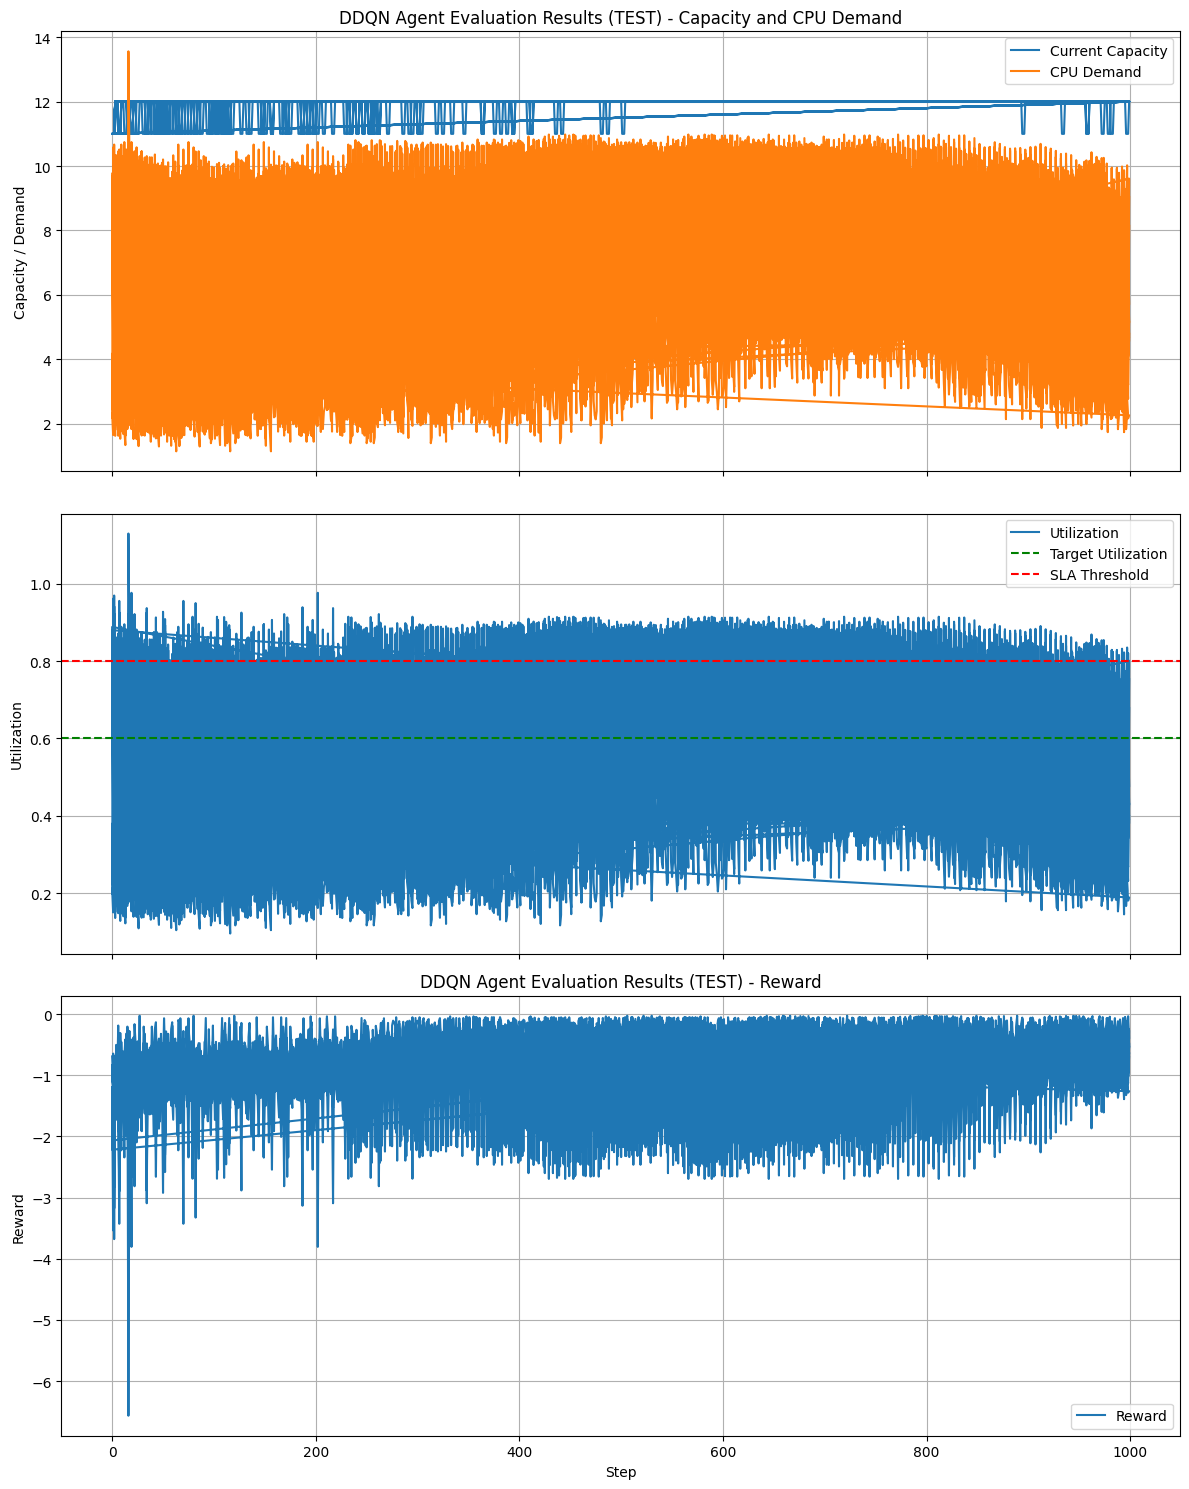

In [ ]:
# 6. Define the evaluation hyperparameters for the Double DQN agent
num_evaluation_episodes_ddqn = 10
max_steps_per_evaluation_episode_ddqn = 1000

# 7. Call the evaluate_agent function

# Validation evaluation
ddqn_val_scores, eval_results_val = evaluate_agent(
    agent_ddqn,
    env_ddqn,
    num_evaluation_episodes_ddqn,
    max_steps_per_evaluation_episode_ddqn,
    split="val",
    use_random_windows=True
)

# Test evaluation
ddqn_test_scores, eval_results_test = evaluate_agent(
    agent_ddqn,
    env_ddqn,
    num_evaluation_episodes_ddqn,
    max_steps_per_evaluation_episode_ddqn,
    split="test",
    use_random_windows=True
)

# Choose which split to plot
df = eval_results_test      # or eval_results_val if you want validation

# 7. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 15), sharex=True)

# 8. Plot Current Capacity and CPU Demand
axes[0].plot(df.index, df['current_capacity'], label='Current Capacity')
axes[0].plot(df.index, df['demand_cpu'], label='CPU Demand')
axes[0].set_ylabel('Capacity / Demand')
axes[0].set_title('DDQN Agent Evaluation Results (TEST) - Capacity and CPU Demand')
axes[0].legend()
axes[0].grid(True)

# 9. Plot Utilization and Target Utilization
axes[1].plot(df.index, df['utilization'], label='Utilization')
axes[1].axhline(y=env_ddqn.target_utilization, color='g', linestyle='--', label='Target Utilization')
axes[1].axhline(y=env_ddqn.sla_threshold, color='r', linestyle='--', label='SLA Threshold')
axes[1].set_ylabel('Utilization')
axes[1].legend()
axes[1].grid(True)

# 10. Plot Reward
axes[2].plot(df.index, df['reward'], label='Reward')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Reward')
axes[2].set_title('DDQN Agent Evaluation Results (TEST) - Reward')
axes[2].legend()
axes[2].grid(True)

# 11. Adjust layout and display plots
plt.tight_layout()
plt.show()